In [1]:
!pip install pandas
!pip install wordcloud
!pip install gensim
!pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install pyLDAvis


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install stopwordsiso


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

df = pd.read_csv("headlines_train.csv")

print("Original:", len(df))

df = df.dropna(subset=["text"])

df["text"] = df["text"].str.strip()

df = df[df["text"] != ""]

df = df.drop_duplicates(subset=["text"])

df = df.reset_index(drop=True)

print("After cleaning:", len(df))

df

Original: 50000
After cleaning: 4845


,text,label,is_clickbait
0,Transfer rumors suggest a record deal for the ...,sports,0
1,Messi scores a stunning goal in the Champions ...,sports,0
2,How to speed up your computer with simple tweaks,tech,0
3,Coach explains new defensive tactics after the...,sports,0
4,"Central bank cuts rates, markets rally on dovi...",finance,0
...,...,...,...
4840,97 Messi scores a stunning goal in the Champio...,sports,0
4841,72 She did X — what happens next will shock you,clickbait,0
4842,46 „Apple“ pristatė naują iPhone su pažangia k...,tech,0
4843,31 Startuolis pritraukė 50 mln. USD DI platfor...,tech,0


In [5]:
sample_20 = df.sample(n=20, random_state=42)

for i, text in enumerate(sample_20["text"], 1):
    print(f"{i:2}: {text}")

 1: 4 Top 7 paslaptys, kurias įmonės nenori, kad žinotumėte — Read more
 2: 28 Coach explains new defensive tactics after the game
 3: Top 7 paslaptys, kurias įmonės nenori, kad žinotumėte — You won't believe it (Berlin)
 4: 88 Open-source libraries accelerate machine learning workflows analitikų teigimu
 5: 31 Local team wins national championship in overtime
 6: 85 Local team wins national championship in overtime
 7: Top 7 secrets companies don't want you to know — Number 5 is shocking (London)
 8: 66 Atviro kodo bibliotekos pagreitina mašininio mokymosi procesus
 9: 79 Didelė saugumo spraga paveikė milijonus vartotojų dėl rinkos reakcijos
10: 10 Kaip pagreitinti kompiuterį paprastais triukais
11: 54 Major security breach affects millions of users worldwide po pranešimo (Paris)
12: 93 Star player signs a multi-year contract with club
13: 91 Messi įmušė įspūdingą įvartį Lygų taurėje
14: 41 She did X — what happens next will shock you (Paris)
15: 62 Coach explains new defensive tactic

In [6]:
# Load the regular expression library
import re

# Remove punctuation
df["text_processed"] = df["text"].map(lambda x: re.sub('[,.!?]', '', x))

# Convert the titles to lowercase
df["text_processed"] = df["text_processed"].map(lambda x: x.lower())

# Print out the first rows of papers
df["text_processed"].head()

0    transfer rumors suggest a record deal for the ...
1    messi scores a stunning goal in the champions ...
2     how to speed up your computer with simple tweaks
3    coach explains new defensive tactics after the...
4    central bank cuts rates markets rally on dovis...
Name: text_processed, dtype: str

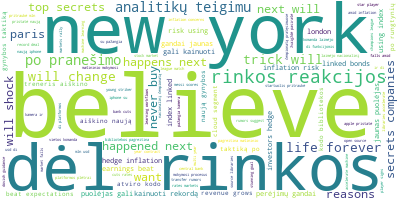

In [7]:
# Import the wordcloud library
from wordcloud import WordCloud

# Join the different processed titles together.
long_string = ','.join(list(df["text_processed"].values))

# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

In [8]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]

data = df.text_processed.values.tolist()
data_words = list(sent_to_words(data))

# remove stop words
data_words = remove_stopwords(data_words)
print(data_words[:1][0][:30])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\админ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['transfer', 'rumors', 'suggest', 'record', 'deal', 'young', 'striker', 'analitiku', 'teigimu']


In [9]:
import gensim.corpora as corpora

# Create Dictionary
id2word = corpora.Dictionary(data_words)

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in data_words]

# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1)]


In [10]:
from pprint import pprint

# number of topics
num_topics = 3
num_topics_1 = 7

# Build LDA model
lda_model_1 = gensim.models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics,
    random_state=42,
    passes=15
)

lda_model_2 = gensim.models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics_1,
    random_state=42,
    passes=15
)

pprint(lda_model_1.print_topics())
doc_lda = lda_model_1[corpus]

pprint(lda_model_2.print_topics())
doc_lda_1 = lda_model_2[corpus]

[(0,
  '0.028*"believe" + 0.018*"change" + 0.018*"life" + 0.018*"forever" + '
  '0.018*"trick" + 0.017*"po" + 0.017*"markets" + 0.016*"next" + '
  '0.015*"happened" + 0.014*"breach"'),
 (1,
  '0.034*"concerns" + 0.034*"amid" + 0.029*"rinkos" + 0.029*"del" + '
  '0.029*"reakcijos" + 0.026*"new" + 0.019*"inflation" + 0.018*"record" + '
  '0.018*"falls" + 0.018*"stock"'),
 (2,
  '0.019*"su" + 0.018*"apple" + 0.018*"iphone" + 0.014*"new" + '
  '0.011*"analysts" + 0.010*"pazangia" + 0.010*"ir" + 0.010*"funkcijomis" + '
  '0.010*"pristate" + 0.010*"kamera"')]
[(0,
  '0.040*"change" + 0.040*"trick" + 0.040*"life" + 0.040*"forever" + '
  '0.030*"security" + 0.030*"affects" + 0.030*"millions" + 0.030*"major" + '
  '0.030*"breach" + 0.030*"users"'),
 (1,
  '0.041*"new" + 0.035*"record" + 0.035*"rumors" + 0.035*"deal" + '
  '0.035*"transfer" + 0.035*"suggest" + 0.035*"young" + 0.035*"striker" + '
  '0.034*"explains" + 0.034*"coach"'),
 (2,
  '0.033*"new" + 0.033*"happens" + 0.033*"shock" + 0.033*

In [11]:
for topic_id, words in lda_model_1.show_topics(
    num_topics=num_topics,
    num_words=10,
    formatted=False
):
    print(f"\nTopic {topic_id + 1}:")
    
    for word, weight in words:
        print(word, round(weight, 4))

for topic_id, words in lda_model_2.show_topics(
    num_topics=num_topics_1,
    num_words=10,
    formatted=False
):
    print(f"\nTopic {topic_id + 1}:")
    
    for word, weight in words:
        print(word, round(weight, 4))


Topic 1:
believe 0.0281
change 0.0179
life 0.0179
forever 0.0179
trick 0.0179
po 0.0168
markets 0.0166
next 0.0159
happened 0.0146
breach 0.0135

Topic 2:
concerns 0.0339
amid 0.0339
rinkos 0.0286
del 0.0286
reakcijos 0.0286
new 0.0261
inflation 0.0186
record 0.0176
falls 0.0175
stock 0.0175

Topic 3:
su 0.0191
apple 0.018
iphone 0.018
new 0.0141
analysts 0.0114
pazangia 0.0102
ir 0.0102
funkcijomis 0.0102
pristate 0.0102
kamera 0.0102

Topic 1:
change 0.0397
trick 0.0397
life 0.0397
forever 0.0397
security 0.03
affects 0.03
millions 0.03
major 0.03
breach 0.03
users 0.03

Topic 2:
new 0.0412
record 0.0348
rumors 0.0348
deal 0.0348
transfer 0.0348
suggest 0.0348
young 0.0348
striker 0.0348
explains 0.0344
coach 0.0344

Topic 3:
new 0.0332
happens 0.033
shock 0.033
next 0.0328
hedge 0.032
risk 0.032
using 0.032
linked 0.032
bonds 0.032
index 0.032

Topic 4:
markets 0.0266
analysts 0.0259
jaunas 0.0233
gandai 0.0233
perejimu 0.0233
puolejas 0.0233
rekorda 0.0233
kainuoti 0.0233
gali 0.0

In [12]:
import stopwordsiso as stopwords

eng_stop_words = stopwords.stopwords("en")
lt_stop_words = stopwords.stopwords("lt")

stop_words_1 = eng_stop_words | lt_stop_words

def sent_to_words_1(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords_1(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words_1] for doc in texts]

data_1 = df.text_processed.values.tolist()
data_words_1 = list(sent_to_words_1(data_1))

# remove stop words
data_words_1 = remove_stopwords_1(data_words_1)
print(data_words_1[:1][0][:30])

['transfer', 'rumors', 'record', 'deal', 'striker', 'analitiku', 'teigimu']


In [13]:
# Create Dictionary
id2word_1 = corpora.Dictionary(data_words_1)

# Term Document Frequency
corpus_1 = [id2word_1.doc2bow(text) for text in data_words_1]

# View
print(corpus_1[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1)]


In [14]:
# Build LDA model
lda_model_2 = gensim.models.LdaModel(
    corpus=corpus_1,
    id2word=id2word_1,
    num_topics=num_topics,
    random_state=42,
    passes=15
)

lda_model_3 = gensim.models.LdaModel(
    corpus=corpus_1,
    id2word=id2word_1,
    num_topics=num_topics_1,
    random_state=42,
    passes=15
)

pprint(lda_model_2.print_topics())
doc_lda_2 = lda_model_2[corpus_1]

pprint(lda_model_3.print_topics())
doc_lda_3 = lda_model_3[corpus_1]

[(0,
  '0.029*"change" + 0.029*"life" + 0.029*"trick" + 0.023*"happened" + '
  '0.022*"reasons" + 0.022*"gadget" + 0.022*"major" + 0.022*"users" + '
  '0.022*"worldwide" + 0.022*"breach"'),
 (1,
  '0.030*"markets" + 0.030*"apple" + 0.030*"iphone" + 0.028*"record" + '
  '0.019*"analysts" + 0.017*"nauja" + 0.017*"di" + 0.017*"kamera" + '
  '0.017*"pazangia" + 0.017*"funkcijomis"'),
 (2,
  '0.024*"inflation" + 0.021*"messi" + 0.018*"concerns" + 0.012*"linked" + '
  '0.012*"bonds" + 0.012*"hedge" + 0.012*"investors" + 0.012*"risk" + '
  '0.012*"falls" + 0.012*"stock"')]
[(0,
  '0.068*"gadget" + 0.068*"reasons" + 0.062*"accelerate" + 0.062*"workflows" + '
  '0.062*"source" + 0.062*"machine" + 0.062*"libraries" + 0.062*"learning" + '
  '0.060*"saugumo" + 0.060*"paveike"'),
 (1,
  '0.058*"markets" + 0.044*"shock" + 0.042*"revenue" + 0.042*"segment" + '
  '0.042*"cloud" + 0.042*"earnings" + 0.042*"beat" + 0.042*"grows" + '
  '0.042*"expectations" + 0.041*"guidance"'),
 (2,
  '0.048*"messi" + 0

In [15]:
for topic_id, words in lda_model_2.show_topics(
    num_topics=num_topics,
    num_words=10,
    formatted=False
):
    print(f"\nTopic {topic_id + 1}:")
    
    for word, weight in words:
        print(word, round(weight, 4))

for topic_id, words in lda_model_3.show_topics(
    num_topics=num_topics_1,
    num_words=10,
    formatted=False
):
    print(f"\nTopic {topic_id + 1}:")
    
    for word, weight in words:
        print(word, round(weight, 4))


Topic 1:
change 0.0287
life 0.0287
trick 0.0287
happened 0.0233
reasons 0.0218
gadget 0.0218
major 0.0217
users 0.0217
worldwide 0.0217
breach 0.0217

Topic 2:
markets 0.0304
apple 0.0299
iphone 0.0299
record 0.0283
analysts 0.0194
nauja 0.0173
di 0.0171
kamera 0.017
pazangia 0.017
funkcijomis 0.017

Topic 3:
inflation 0.0237
messi 0.021
concerns 0.0177
linked 0.012
bonds 0.012
hedge 0.012
investors 0.012
risk 0.012
falls 0.0118
stock 0.0118

Topic 1:
gadget 0.068
reasons 0.068
accelerate 0.0618
workflows 0.0618
source 0.0618
machine 0.0618
libraries 0.0618
learning 0.0618
saugumo 0.0598
paveike 0.0598

Topic 2:
markets 0.0582
shock 0.044
revenue 0.0415
segment 0.0415
cloud 0.0415
earnings 0.0415
beat 0.0415
grows 0.0415
expectations 0.0415
guidance 0.0414

Topic 3:
messi 0.0485
perejimu 0.027
puolejas 0.027
rekorda 0.027
kainuoti 0.027
gali 0.027
jaunas 0.027
gandai 0.027
player 0.0261
club 0.0261

Topic 4:
kompiuteri 0.0306
triukais 0.0306
paprastais 0.0306
pagreitinti 0.0306
cempio

In [16]:
def predict_topic(headline):
    headline = re.sub('[,.!?]', '', headline.lower())

    words = list(sent_to_words([headline]))[0]
    words = [word for word in words if word not in stop_words_1]

    bow = id2word_1.doc2bow(words)

    if len(bow) == 0:
        print("No known words.")
        return

    topics = lda_model_2.get_document_topics(bow)

    best_topic = max(topics, key=lambda x: x[1])

    print("Topic:", best_topic[0] + 1)
    print("Probability:", round(best_topic[1] * 100, 1), "%")

In [28]:
headline = input("Enter headline: ")
predict_topic(headline)

No known words.
